# Deep Learning for Image Classification — Corn (Maize) Leaf Disease

**Assignment:** Deep Learning for Image Classification & Segmentation — Image Analysis Group 9
**Task chosen:** Classification (4-class corn leaf disease), CNN baseline vs. ResNet18 transfer learning.

---

## > READ THIS FIRST — this notebook does **not** train anything

**The models are already trained.** Training was completed ahead of time with `train.py`, and the
resulting weights live in `checkpoints/`. This notebook is the **written report + evidence**, not a
training demo.

| | |
|---|---|
| **What this notebook DOES** | Loads the already-trained checkpoints, runs **inference only** on the held-out test set, and reports metrics, curves, confusion matrices, and the baseline-vs-advanced comparison. |
| **What this notebook does NOT do** | Train. Fine-tune. Overwrite `checkpoints/`. Overwrite `results/`. Overwrite `plots/`. |
| **Runtime** | ~1–2 minutes on CPU (test-set inference over 578 images, twice). |
| **Safety** | Every plotting call below passes `save_path=None`, so **nothing on disk is modified**. The notebook is strictly read-only with respect to your trained artifacts. |

The one training cell in Section 2.3 is **guarded by `RETRAIN = False`** and will refuse to run. It
exists to document *how* the checkpoints were produced, not to reproduce them here (that took ~4.3
hours on CPU).

> **Why it is built this way:** re-training inside a notebook would overwrite the exact checkpoints
> these results describe, so the numbers in the report would no longer match the weights on disk.
> Evaluation is cheap, deterministic, and reproducible; training is neither. So we re-run evaluation
> live and read training history from the logs that the real training run wrote.

---

## How this notebook maps to the assignment

| Assignment task | Section |
|---|---|
| 1. Dataset Selection & Preparation | [Section 1](#task-1) |
| — Choose a dataset | 1.1 |
| — Preprocessing: resizing, normalization, augmentation (rotation, flipping, noise injection) | 1.2 |
| — Document dataset challenges (imbalance, noise, resolution) | 1.3 |
| 2. Model Training | [Section 2](#task-2) |
| — CNN baseline + one advanced model (ResNet18) | 2.1 |
| — Hyperparameter tuning (learning rate, batch size, optimizer) | 2.2, 2.4 |
| — Regularization (dropout, weight decay) + overfitting monitoring | 2.2, 2.3 |
| 3. Evaluation | [Section 3](#task-3) |
| — Accuracy, precision, recall, F1, ROC-AUC | 3.1, 3.2 |
| — Confusion matrices + training/validation curves | 2.3, 3.3 |
| — Compare baseline vs. advanced | 3.5 |
| 4. Deliverables | [Section 4](#task-4) |

## Setup

Imports the project's own modules, so this notebook calls the **exact same functions** as `train.py`,
`evaluate.py`, and `predict.py` — no duplicated logic, no reimplemented metrics.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Make the project root importable whether the notebook is run from notebook/ or the repo root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

import config
from models import get_model
from utils.dataset import CornLeafDataset, compute_class_weights
from utils.metrics import compute_metrics, count_parameters, model_size_mb
from utils.transforms import denormalize, get_eval_transforms, get_train_transforms
from utils.visualize import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_model_comparison,
    plot_precision_recall_curve,
    plot_roc_curve,
    plot_sample_images,
    plot_training_curves,
)

config.set_seed(config.SEED)  # reproducible sampling / augmentation previews

MODELS = ["baseline", "resnet18"]
PRETTY = {"baseline": "Baseline CNN (from scratch)", "resnet18": "ResNet18 (ImageNet transfer)"}

print(f"Project root : {PROJECT_ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {config.DEVICE}")
print(f"Seed         : {config.SEED}")
print(f"Classes ({config.NUM_CLASSES}) : {config.CLASS_SHORT_NAMES}")

Project root : C:\Users\warob\OneDrive\Desktop\DeepLearingAssignment
PyTorch      : 2.12.1+cpu
Device       : cpu
Seed         : 42
Classes (4) : ['Gray Leaf Spot', 'Common Rust', 'Healthy', 'Northern Leaf Blight']


### Confirm the trained checkpoints exist

This cell is the proof that **training already happened**. It reads the checkpoint files written by
`train.py` and reports which epoch each one was saved at. If this table renders, there is nothing to
retrain.

In [2]:
rows = []
for name in MODELS:
    ckpt_path = config.best_ckpt_path(name)
    if not ckpt_path.exists():
        rows.append({"model": name, "checkpoint": "MISSING — run `python train.py`", "status": "X"})
        continue

    ckpt = torch.load(ckpt_path, map_location="cpu")
    meta_path = config.model_results_dir(name) / "training_meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.exists() else {}

    rows.append({
        "model": name,
        "checkpoint": ckpt_path.name,
        "size_mb": model_size_mb(ckpt_path),
        "saved_at_epoch": ckpt.get("epoch"),
        "val_acc_at_save": round(ckpt.get("val_acc", float("nan")), 4),
        "epochs_run": meta.get("epochs_run"),
        "train_time_min": round(meta.get("training_time_seconds", 0) / 60, 1),
        "status": "trained",
    })

checkpoint_inventory = pd.DataFrame(rows)
display(checkpoint_inventory)

assert all(r.get("status") == "trained" for r in rows), (
    "A checkpoint is missing. This notebook does not train — run `python train.py --model both` first."
)
print("\nBoth models are trained. This notebook will load these weights and run inference only.")

,model,checkpoint,size_mb,saved_at_epoch,val_acc_at_save,epochs_run,train_time_min,status
0,baseline,baseline_best.pth,1.63,23,0.9654,30,104.4,trained
1,resnet18,resnet18_best.pth,42.72,12,0.9723,26,154.4,trained



Both models are trained. This notebook will load these weights and run inference only.


<a id="task-1"></a>
# Task 1 — Dataset Selection & Preparation

---

## 1.1 Dataset selection

**Dataset: Corn (maize) leaf disease subset of PlantVillage** — 3,852 RGB JPEG images (~256×256),
4 classes.

| Class | Short name | Images | Share |
|---|---|---:|---:|
| `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot` | Gray Leaf Spot | 513 | 13.3% |
| `Corn_(maize)___Common_rust_` | Common Rust | 1,192 | 30.9% |
| `Corn_(maize)___healthy` | Healthy | 1,162 | 30.2% |
| `Corn_(maize)___Northern_Leaf_Blight` | Northern Leaf Blight | 985 | 25.6% |
| | **Total** | **3,852** | 100% |

**Why this dataset.** It is a genuine agricultural diagnostic problem (real economic value), it is
small enough to train twice on CPU within a few hours, and — crucially for a meaningful assignment —
it contains **two visually confusable classes** (Gray Leaf Spot and Northern Leaf Blight both present
as elongated tan/grey necrotic lesions). That gives the evaluation section something real to analyse
instead of a saturated 100% score.

### Splitting strategy

The raw archive ships pre-split into `PlantVillage/train/` and `PlantVillage/val/` only — **there is
no test split**, so a held-out test set had to be constructed. `utils/split_data.py` pools every
image per class from both raw folders and performs a **deterministic (seed=42), stratified 70/15/15
re-split** into train / validation / test.

Rather than physically copying ~3,850 images into new folders, the split is stored as **manifest
CSVs** (`filepath,label,label_idx`) in `dataset/splits/`. Every `Dataset` in the project reads from
these manifests. This is:

- **reproducible** — same seed → byte-identical manifests,
- **cheap** — no duplication of ~60 MB of images on disk,
- **honest** — the test split is touched exactly once, at evaluation time.

In [3]:
from utils.split_data import build_splits

# No-op when the manifests already exist. (force=True would regenerate them identically, seed=42.)
build_splits(force=False)

split_frames = {
    "train": pd.read_csv(config.TRAIN_MANIFEST),
    "val": pd.read_csv(config.VAL_MANIFEST),
    "test": pd.read_csv(config.TEST_MANIFEST),
}

dist = pd.DataFrame({
    split: df["label"].value_counts().reindex(config.CLASS_NAMES, fill_value=0).values
    for split, df in split_frames.items()
}, index=config.CLASS_SHORT_NAMES)
dist["total"] = dist.sum(axis=1)
dist.loc["TOTAL"] = dist.sum(axis=0)

print("Images per class per split (70 / 15 / 15, stratified, seed=42)\n")
display(dist)

print("Split sizes:", {k: len(v) for k, v in split_frames.items()})
print(f"Total images: {sum(len(v) for v in split_frames.values())}")

# Sanity check: no image leaks across splits.
all_paths = pd.concat([df["filepath"] for df in split_frames.values()])
assert all_paths.duplicated().sum() == 0, "Leakage: an image appears in more than one split!"
print("\nNo overlap between train / val / test — verified.")

2026-07-09 15:54:05 | INFO     | utils.split_data | Manifests already exist, skipping split generation (use force=True to rebuild).


Images per class per split (70 / 15 / 15, stratified, seed=42)



,train,val,test,total
Gray Leaf Spot,359,77,77,513
Common Rust,834,179,179,1192
Healthy,813,174,175,1162
Northern Leaf Blight,690,148,147,985
TOTAL,2696,578,578,3852


Split sizes: {'train': 2696, 'val': 578, 'test': 578}
Total images: 3852

No overlap between train / val / test — verified.


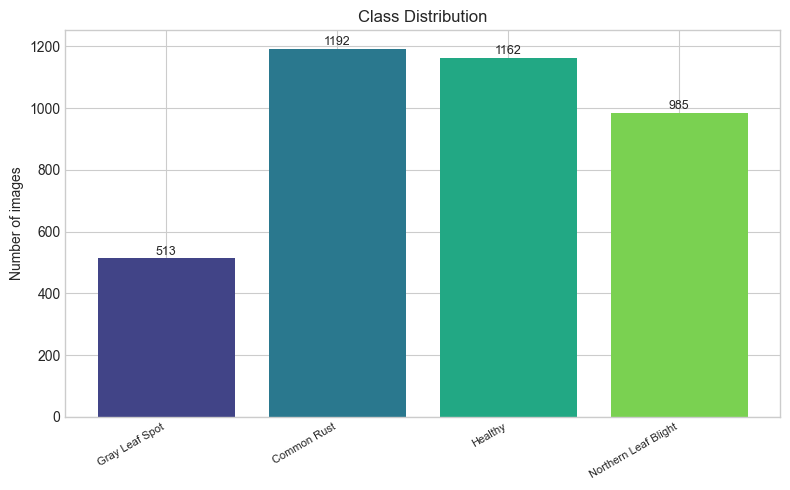

In [4]:
stats = json.loads((config.RESULTS_DIR / "dataset_stats.json").read_text(encoding="utf-8"))
counts_short = dict(zip(config.CLASS_SHORT_NAMES, [stats["per_class"][c] for c in config.CLASS_NAMES]))

fig = plot_class_distribution(counts_short, save_path=None)  # save_path=None -> read-only
plt.show()

## 1.2 Preprocessing & augmentation

The assignment asks specifically for **resizing, normalization, and augmentation (rotation, flipping,
noise injection)**. All four are implemented in `utils/transforms.py`. Here is the full mapping:

| Assignment requirement | Implementation | Rationale |
|---|---|---|
| **Resizing** | `RandomResizedCrop(224, scale=(0.8, 1.0))` (train) / `Resize(224)` (eval) | 224×224 is the native input size of the ImageNet-pretrained ResNet18. Applied identically to the baseline CNN so the comparison is fair. |
| **Normalization** | `Normalize(ImageNet mean/std)` | Required to match the statistics the pretrained ResNet18 backbone expects. Applied to both models for parity. |
| **Rotation** | `RandomRotation(degrees=20)` | Leaf photographs have no canonical orientation. |
| **Flipping** | `RandomHorizontalFlip(p=0.5)` | A mirrored leaf is still the same disease — a free doubling of effective data. |
| **Noise injection** | `AddGaussianNoise(std=0.05)`, applied with `p=0.3` after `ToTensor()` | Simulates sensor noise and JPEG artefacts in field-captured photos. Custom `nn.Module` (see `utils/transforms.py`). |
| *(extra)* Colour jitter | `ColorJitter(brightness/contrast/saturation=0.2, hue=0.05)` | Robustness to sunlight/shade and white-balance variation. |
| *(extra)* Affine + perspective | `RandomAffine(translate=0.1, shear=10)`, `RandomPerspective(0.2, p=0.3)` | Robustness to camera viewpoint and off-axis capture. |

**Critical detail: augmentation is applied to the training split only.** Validation, test, and
inference all use a deterministic `Resize → ToTensor → Normalize` pipeline. If augmentation leaked
into evaluation, the reported test metrics would be noisy and would not reflect real-world inference.

In [5]:
print("TRAIN pipeline (stochastic — augmentation ON):")
print(get_train_transforms())
print("\n" + "=" * 78 + "\n")
print("EVAL / TEST / INFERENCE pipeline (deterministic — augmentation OFF):")
print(get_eval_transforms())

TRAIN pipeline (stochastic — augmentation ON):
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), shear=[-10.0, 10.0])
    RandomPerspective(p=0.3)
    ToTensor()
    RandomApply(
    p=0.3
    AddGaussianNoise()
)
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


EVAL / TEST / INFERENCE pipeline (deterministic — augmentation OFF):
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Augmentation preview — different images

Twelve training images drawn through the full augmentation pipeline, then de-normalized for display.
Note the varied crops, rotations, colour shifts and (on some) visible noise grain.

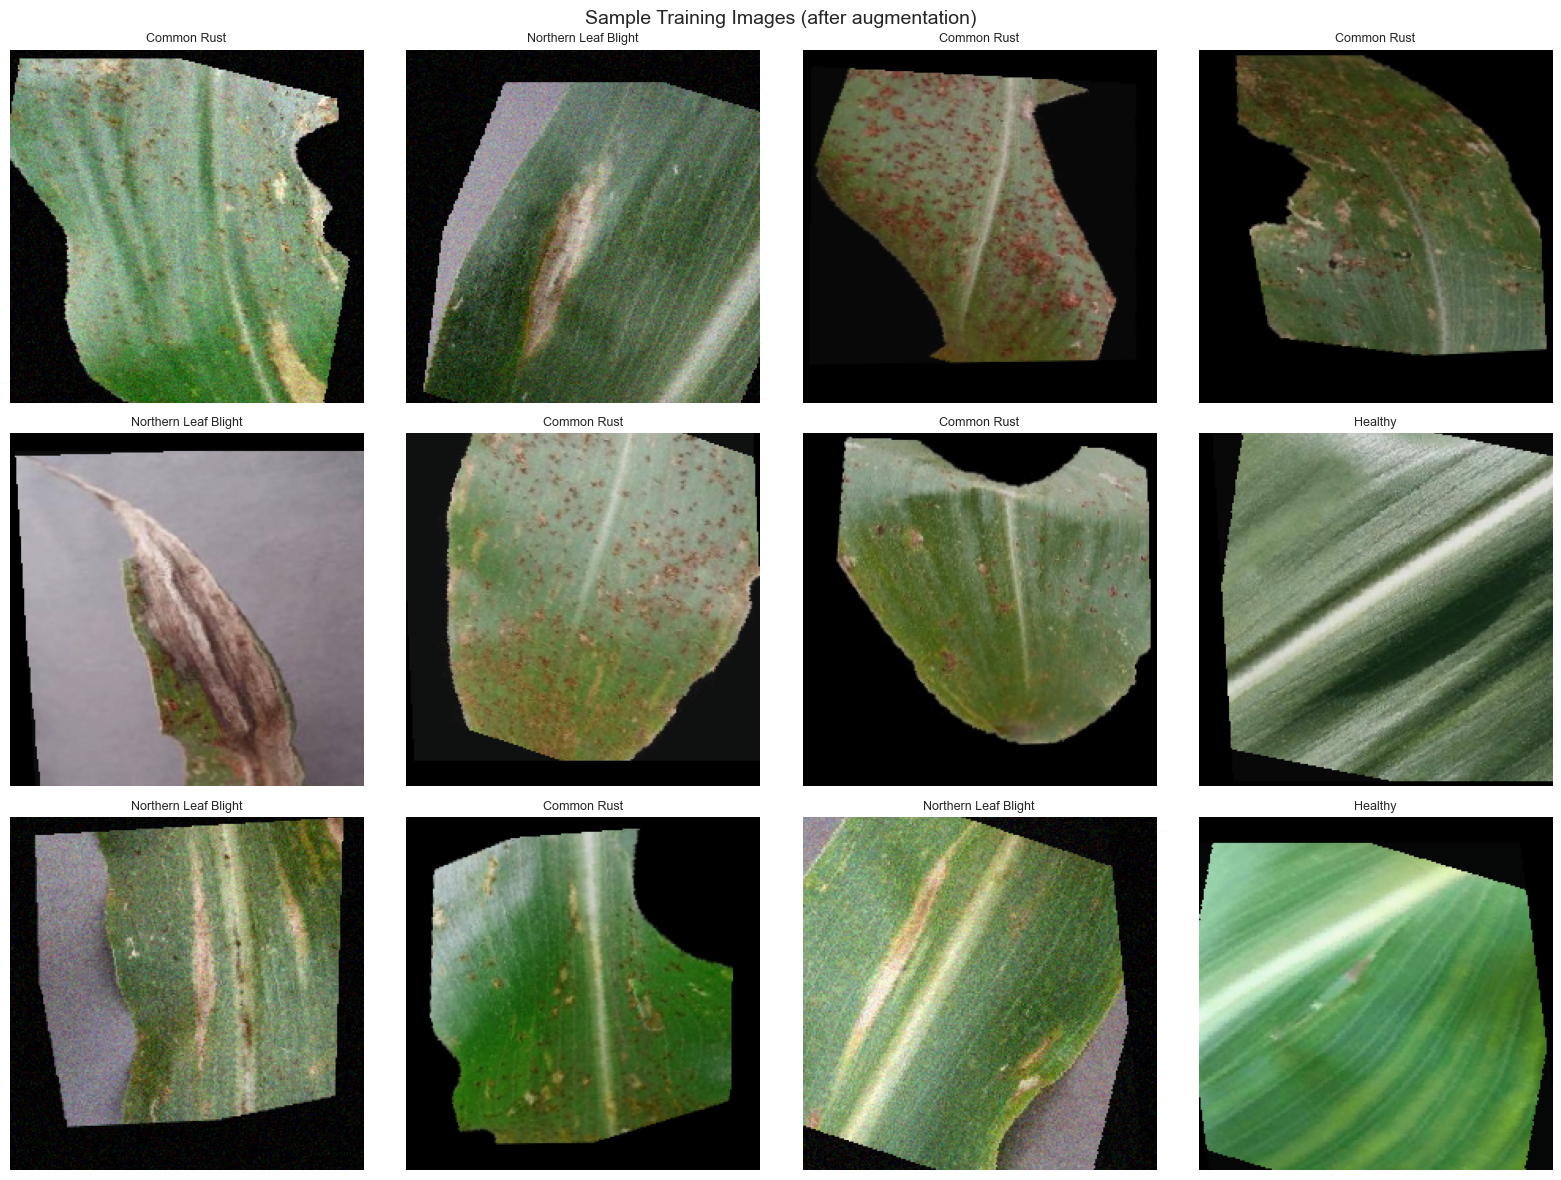

In [6]:
preview_ds = CornLeafDataset(config.TRAIN_MANIFEST, transform=get_train_transforms())
fig = plot_sample_images(preview_ds, config.CLASS_SHORT_NAMES, save_path=None, n=12)
plt.show()

### Augmentation preview — the *same* image, eight times

This is the clearest demonstration that augmentation is stochastic: one source image, eight
independent draws from the pipeline. The network effectively never sees the same pixels twice, which
is what suppresses memorisation of the 2,696 training images.

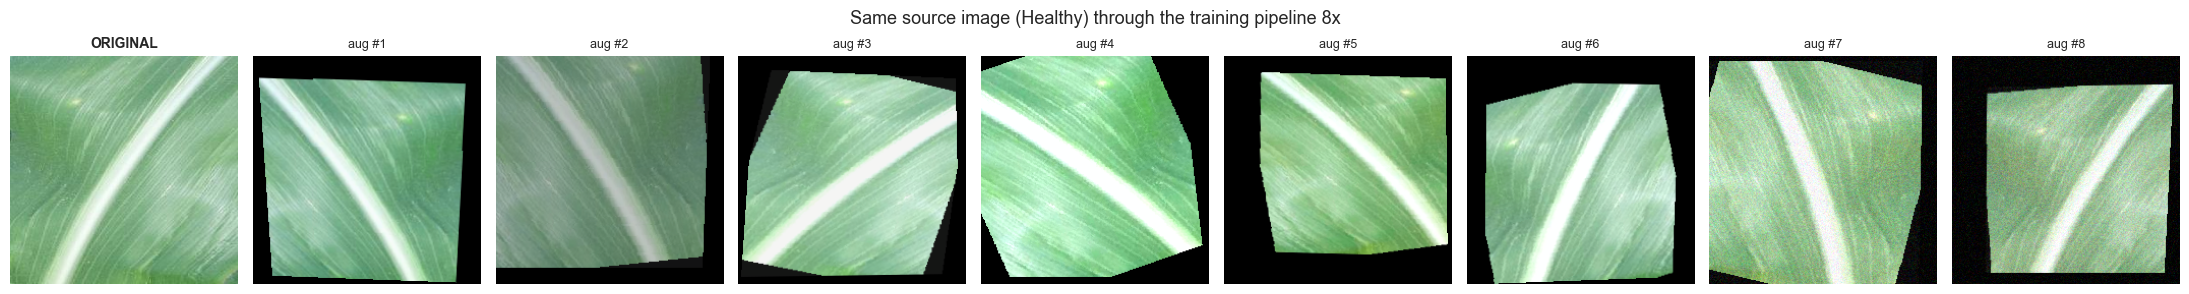

In [7]:
SOURCE_IDX = 0
raw_path = preview_ds.df.iloc[SOURCE_IDX]["filepath"]
raw_label = config.CLASS_SHORT_NAMES[int(preview_ds.df.iloc[SOURCE_IDX]["label_idx"])]

from PIL import Image
original = Image.open(raw_path).convert("RGB")
train_tf = get_train_transforms()

fig, axes = plt.subplots(1, 9, figsize=(22, 3))
axes[0].imshow(original)
axes[0].set_title("ORIGINAL", fontsize=10, fontweight="bold")
axes[0].axis("off")
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(denormalize(train_tf(original)))
    ax.set_title(f"aug #{i}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Same source image ({raw_label}) through the training pipeline 8x", fontsize=13)
fig.tight_layout()
plt.show()

## 1.3 Dataset challenges

The assignment asks to *document dataset challenges (class imbalance, noise, resolution
differences)*. All three are present. Each is stated below with the concrete mitigation used.

### (a) Class imbalance — **the dominant challenge**

Common Rust has **2.32×** the images of Gray Leaf Spot (1,192 vs 513). Left alone, a model can score
~31% by predicting "Common Rust" for everything, and the minority class gets systematically
under-predicted.

**Two independent mitigations, both in `utils/dataset.py`:**

1. **`WeightedRandomSampler`** — training batches are sampled with probability ∝ 1/class frequency,
   so each batch is approximately class-balanced regardless of the underlying distribution.
2. **Inverse-frequency class weights in `CrossEntropyLoss`** — the loss for a misclassified Gray Leaf
   Spot image is weighted **1.877×**, versus **0.808×** for Common Rust.

Note that *no images were duplicated on disk* — oversampling is done at the sampler level, which
avoids inflating the dataset and keeps the val/test splits untouched and honest.

### (b) Visual similarity between classes — the hardest, and unfixable by preprocessing

**Gray Leaf Spot** and **Northern Leaf Blight** both manifest as elongated, tan-to-grey necrotic
lesions running parallel to the leaf veins. They differ mainly in lesion margin sharpness and length
— a distinction that is subtle even for trained agronomists. As Section 3.4 shows, **this single
pair accounts for ~85% of all test-set errors in both models.** No amount of augmentation fixes this;
it is an intrinsic property of the label space.

### (c) Noise & background clutter

Field photographs include soil, hands, adjacent leaves, and shadows. JPEG compression adds block
artefacts. Mitigated by the augmentation pipeline (random crop, affine, perspective) and by explicit
**Gaussian noise injection** (`std=0.05, p=0.3`), which forces the network to rely on lesion texture
rather than on incidental high-frequency detail.

### (d) Resolution & lighting variance

Source images are nominally ~256×256 but vary. All splits are resized to a fixed 224×224 and
normalized with ImageNet statistics, so the two models receive pixel-identical inputs and the
comparison isolates *architecture* as the only variable.

In [8]:
train_ds = CornLeafDataset(config.TRAIN_MANIFEST, transform=None)
counts = train_ds.class_counts()
weights = compute_class_weights(train_ds)

imbalance = pd.DataFrame({
    "train_images": counts.values,
    "share_%": (counts.values / counts.values.sum() * 100).round(1),
    "loss_weight": weights.numpy().round(3),
    "sampler_prob_∝": (1.0 / counts.values / (1.0 / counts.values).sum()).round(3),
}, index=config.CLASS_SHORT_NAMES)

print("Class imbalance on the TRAIN split, and the two mitigations applied\n")
display(imbalance)

ratio = counts.values.max() / counts.values.min()
print(f"Imbalance ratio (largest : smallest) = {ratio:.2f} : 1")
print(f"Minority class '{config.CLASS_SHORT_NAMES[int(np.argmin(counts.values))]}' is up-weighted "
      f"{weights.numpy().max() / weights.numpy().min():.2f}x relative to the majority class in the loss.")

Class imbalance on the TRAIN split, and the two mitigations applied



,train_images,share_%,loss_weight,sampler_prob_∝
Gray Leaf Spot,359,13.3,1.877,0.418
Common Rust,834,30.9,0.808,0.180
Healthy,813,30.2,0.829,0.185
Northern Leaf Blight,690,25.6,0.977,0.217


Imbalance ratio (largest : smallest) = 2.32 : 1
Minority class 'Gray Leaf Spot' is up-weighted 2.32x relative to the majority class in the loss.


<a id="task-2"></a>
# Task 2 — Model Training

> Reminder: **the training described in this section has already been executed.** Section 2.3 reads
> the history that the real run wrote to `logs/`. The training cell is disabled.

---

## 2.1 Architectures

The assignment requires *a CNN (baseline) and one advanced model*. Both are classification models
(the U-Net / segmentation branch of the assignment was not taken).

### Baseline — `CustomCNN`, trained from scratch (`models/baseline_cnn.py`)

Four repetitions of `Conv2d(3×3) → BatchNorm2d → ReLU → MaxPool(2×2)`, widening 3 → 32 → 64 → 128 →
256 channels, each block halving the spatial resolution (224 → 112 → 56 → 28 → 14). Then
`AdaptiveAvgPool2d(1)` (global average pooling) and a `Dropout → Linear(256→128) → ReLU → Dropout →
Linear(128→4)` head.

Global average pooling instead of a flattened dense layer is what keeps this model at **423 K
parameters** — a flatten would have produced a `Linear(256·14·14 → 128)` layer with 6.4 M parameters
on its own, which on 2,696 training images would overfit badly.

This model is the **performance floor**: it establishes what is achievable with no external data.

### Advanced — `ResNet18` transfer learning (`models/resnet_model.py`)

`torchvision.models.resnet18` with ImageNet-pretrained weights. The final `fc` layer is replaced with
`Dropout(0.4) → Linear(512 → 4)` and the **entire network is fine-tuned end-to-end** (not frozen
feature extraction — `freeze_backbone=True` is available but was not used).

The hypothesis under test: *do ImageNet features (edges, textures, blobs — learned from 1.2 M images)
transfer to leaf-lesion texture, and do they beat a small CNN trained from scratch on 2,696 images?*
Section 3.5 answers this, and the answer is more interesting than expected.

Both models emit **raw logits**. Softmax is applied inside `nn.CrossEntropyLoss` during training and
explicitly via `F.softmax` at inference — the standard PyTorch idiom, for numerical stability.

In [9]:
arch_rows = []
for name in MODELS:
    m = get_model(name, num_classes=config.NUM_CLASSES, pretrained=False)  # pretrained=False: no download, just shape
    n_params = count_parameters(m)
    with torch.no_grad():
        out = m(torch.zeros(1, 3, *config.IMAGE_SIZE))
    arch_rows.append({
        "model": PRETTY[name],
        "trainable_params": f"{n_params:,}",
        "checkpoint_MB": model_size_mb(config.best_ckpt_path(name)),
        "input_shape": "(1, 3, 224, 224)",
        "output_shape": tuple(out.shape),
    })

display(pd.DataFrame(arch_rows).set_index("model"))

ratio = count_parameters(get_model("resnet18", pretrained=False)) / count_parameters(get_model("baseline"))
print(f"ResNet18 has {ratio:.1f}x more trainable parameters than the baseline CNN.")

,trainable_params,checkpoint_MB,input_shape,output_shape
model,,,,
Baseline CNN (from scratch),"422,788",1.63,"(1, 3, 224, 224)","(1, 4)"
ResNet18 (ImageNet transfer),"11,178,564",42.72,"(1, 3, 224, 224)","(1, 4)"


ResNet18 has 26.4x more trainable parameters than the baseline CNN.


In [10]:
# Layer-level view of the baseline CNN (the model we designed ourselves).
print(get_model("baseline", num_classes=config.NUM_CLASSES))

CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

## 2.2 Hyperparameters, optimizer, and regularization

The assignment asks for **hyperparameter tuning (learning rate, batch size, optimizer)** and
**regularization (dropout, weight decay) with overfitting monitoring**. Both are addressed here; the
tuning *search* is discussed honestly in Section 2.4.

### Final hyperparameters (identical for both models — a controlled comparison)

| Setting | Value | Why |
|---|---|---|
| Epochs | 30 (max) | With early stopping, patience 7 on validation loss. |
| Batch size | 32 | Fits comfortably in CPU RAM; a reasonable gradient-noise/throughput trade-off. |
| Optimizer | Adam | Robust default; SGD+momentum is also implemented (`--optimizer sgd`). |
| Learning rate | 1e-3 | Standard Adam starting point. |
| LR schedule | `ReduceLROnPlateau` (factor 0.5, patience 3) | Halves the LR when validation loss plateaus. |
| Weight decay | 1e-4 | **Regularization** — L2 penalty on the weights. |
| Dropout | 0.4 | **Regularization** — in both classifier heads. |
| Loss | `CrossEntropyLoss(weight=inverse_freq)` | Handles the class imbalance from Section 1.3(a). |
| Early stopping | patience 7 on val loss | **Regularization** — stops before memorisation sets in. |
| Mixed precision | auto on CUDA | No-op on CPU (this run was CPU-only). |
| Seed | 42 | Python `random`, NumPy, torch CPU+CUDA, cuDNN deterministic. |

### The four regularizers, and what each defends against

1. **Dropout (0.4)** — stops the classifier head co-adapting to specific features.
2. **Weight decay (1e-4)** — keeps weights small, favouring smoother decision boundaries.
3. **BatchNorm** — stabilises activations and adds mild noise-based regularization.
4. **Early stopping (patience 7 on validation loss)** — the backstop. Section 2.3 shows it firing on
   ResNet18 at epoch 26 and *never* firing on the baseline, which is itself a result.

Plus the heavy augmentation pipeline from Section 1.2, which is regularization by data.

In [11]:
cfg = config.DEFAULT_TRAINING_CONFIG
hyper = pd.DataFrame(
    [(k, v) for k, v in vars(cfg).items() if k != "model_name"],
    columns=["hyperparameter", "value"],
).set_index("hyperparameter")

print("config.DEFAULT_TRAINING_CONFIG — the single source of truth used by train.py\n")
display(hyper)

config.DEFAULT_TRAINING_CONFIG — the single source of truth used by train.py



,value
hyperparameter,
epochs,30
batch_size,32
learning_rate,0.001
weight_decay,0.0001
optimizer,adam
scheduler_patience,3
scheduler_factor,0.5
early_stopping_patience,7
early_stopping_min_delta,0.0001


## 2.3 The completed training runs

> ### This cell will NOT train. `RETRAIN` is `False` by design.
>
> The two checkpoints in `checkpoints/` were produced by these exact commands, run from the terminal
> before this notebook was written:
>
> ```bash
> python -m utils.split_data          # build the manifests (seed=42)
> python train.py --model both        # 30 epochs max, batch 32, Adam, lr 1e-3
> python evaluate.py --model both --compare
> ```
>
> Total wall-clock: **~4.3 hours on CPU** (baseline 104 min + ResNet18 154 min). Re-running it here
> would overwrite the very weights this report describes, and every number below would drift.

In [12]:
# ======================================================================
#  TRAINING IS ALREADY DONE.  This cell is documentation, not execution.
#  It is guarded so that "Run All" can never destroy the trained weights.
# ======================================================================
RETRAIN = False   # <-- Leave False. Set True ONLY to retrain from scratch (~4.3 h on CPU).

if not RETRAIN:
    print("RETRAIN = False  ->  skipping training (this is the intended path).")
    print("Loading the existing checkpoints instead:\n")
    for name in MODELS:
        print(f"  {config.best_ckpt_path(name).relative_to(PROJECT_ROOT)}")
    print("\nTo actually retrain, use the terminal: `python train.py --model both`")
else:
    # Reference implementation — this is precisely what `python train.py --model both` does.
    import argparse
    from train import train_one_model
    from utils.logger import setup_logger

    logger = setup_logger("notebook_train", config.LOGS_DIR / "notebook_train.log")
    args = argparse.Namespace(
        epochs=30, batch_size=32, lr=1e-3, weight_decay=1e-4, optimizer="adam",
        patience=7, dropout=0.4, seed=config.SEED, num_workers=0,
        amp=True, pretrained=True, class_weights=True,
    )
    for name in MODELS:
        train_one_model(name, args, logger)

RETRAIN = False  ->  skipping training (this is the intended path).
Loading the existing checkpoints instead:

  checkpoints\baseline_best.pth
  checkpoints\resnet18_best.pth

To actually retrain, use the terminal: `python train.py --model both`


### Training & validation curves

Read directly from `logs/{model}_history.json`, written by the real training run. These are the
**training/validation curves** the assignment asks for, and they are how overfitting was monitored.

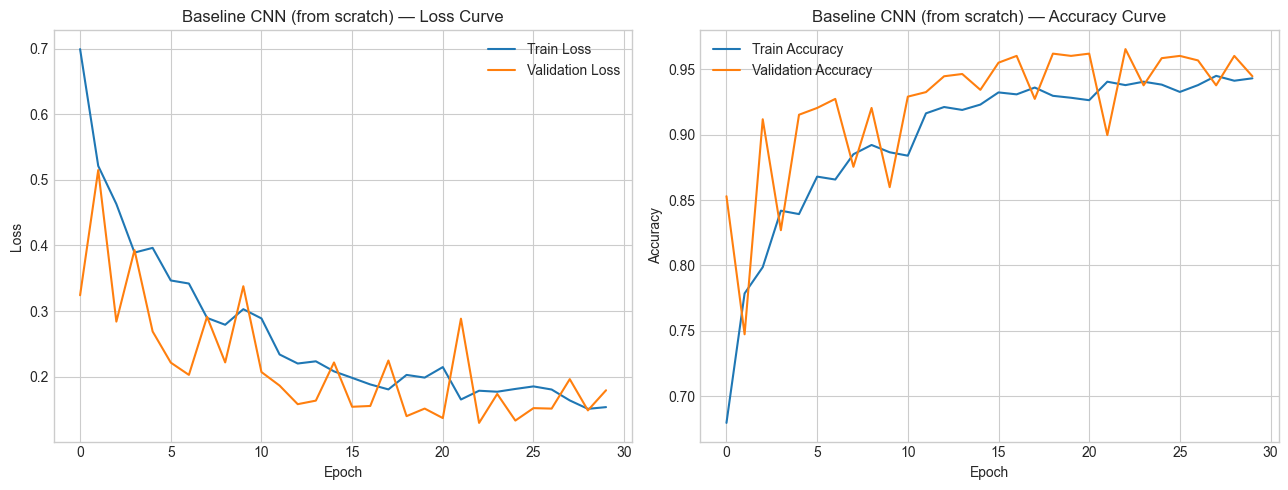

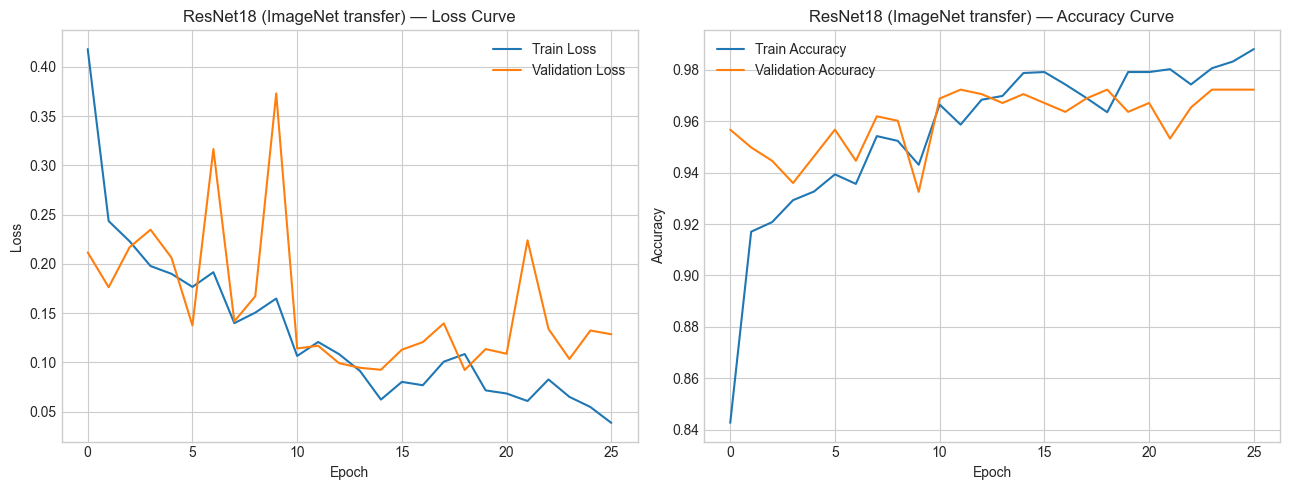

In [13]:
histories = {
    name: json.loads((config.LOGS_DIR / f"{name}_history.json").read_text(encoding="utf-8"))
    for name in MODELS
}

for name, hist in histories.items():
    fig = plot_training_curves(hist, save_path=None, model_name=PRETTY[name])
    plt.show()

### Overfitting analysis

The generalization gap (`train_acc − val_acc`, and the ratio `val_loss / train_loss`) at the final
epoch tells two very different stories.

In [14]:
gap_rows = []
for name, h in histories.items():
    best_ep = int(np.argmax(h["val_acc"])) + 1
    min_loss_ep = int(np.argmin(h["val_loss"])) + 1
    gap_rows.append({
        "model": name,
        "epochs_run": len(h["train_loss"]),
        "final_train_acc": round(h["train_acc"][-1], 4),
        "final_val_acc": round(h["val_acc"][-1], 4),
        "acc_gap (train-val)": round(h["train_acc"][-1] - h["val_acc"][-1], 4),
        "final_train_loss": round(h["train_loss"][-1], 4),
        "final_val_loss": round(h["val_loss"][-1], 4),
        "loss_ratio (val/train)": round(h["val_loss"][-1] / h["train_loss"][-1], 2),
        "best_val_acc": round(max(h["val_acc"]), 4),
        "best_val_acc_epoch": best_ep,
        "min_val_loss_epoch": min_loss_ep,
        "early_stopped": len(h["train_loss"]) < 30,
    })

overfit = pd.DataFrame(gap_rows).set_index("model")
display(overfit.T)

model,baseline,resnet18
epochs_run,30,26
final_train_acc,0.9431,0.9881
final_val_acc,0.9446,0.9723
acc_gap (train-val),-0.0016,0.0158
final_train_loss,0.1535,0.0387
final_val_loss,0.1792,0.1286
loss_ratio (val/train),1.17,3.33
best_val_acc,0.9654,0.9723
best_val_acc_epoch,23,12
min_val_loss_epoch,23,19


**Reading the numbers above:**

**Baseline CNN — no overfitting at all; if anything, mild *under*fitting.**
Final train accuracy 0.9431 vs validation 0.9446 — the validation score is *higher* than training.
That inversion is not a bug: training accuracy is measured on heavily augmented images (random crops,
rotation, colour jitter, injected noise), while validation is measured on clean, deterministically
resized ones. The augmentation is genuinely hard. Early stopping **never fired**; the model ran the
full 30 epochs and was still improving. With 423 K parameters against 2,696 images, this model has
too little capacity to memorise — its regularization is doing more work than it needs to.

**ResNet18 — mild, well-controlled overfitting.**
Final train accuracy 0.9881 vs validation 0.9723 (a 1.58 pp gap), and validation loss is **3.3×**
training loss (0.1286 vs 0.0387). With 11.2 M parameters — 26× the baseline — on the same 2,696
images, that is the expected signature of a model beginning to memorise. It is *controlled*, not
runaway, and the mechanism that controlled it is visible in the table: **minimum validation loss at
epoch 19, early stopping fired at epoch 26** (19 + patience 7). Exactly as designed. The best
checkpoint by validation *accuracy* was saved even earlier, at epoch 12.

**The takeaway for Section 3:** ResNet18 hit its ceiling early and then started fitting noise,
whereas the baseline never had the capacity to. This is the first hint that the extra capacity is not
buying anything on this dataset.

## 2.4 Hyperparameter tuning

`tune.py` implements a grid/random search over the space defined in `config.HP_SEARCH_SPACE`:

| Hyperparameter | Values searched |
|---|---|
| Learning rate | `1e-3`, `5e-4`, `1e-4` |
| Batch size | `16`, `32`, `64` |
| Optimizer | `adam`, `sgd` |

It trains each candidate at a reduced epoch budget, ranks by best validation accuracy, and writes
`results/hyperparam_search.csv`.

### Honest status of this task

> **The search has not been executed.** `results/hyperparam_search.csv` does not exist. The final
> hyperparameters in Section 2.2 are **principled defaults** (Adam @ 1e-3, batch 32) plus an
> *adaptive* schedule — `ReduceLROnPlateau` tunes the learning rate downward during training, and
> early stopping tunes the epoch count. So the learning rate and epoch count were effectively tuned
> online; **batch size and optimizer choice were not searched.**
>
> The cell below runs the real search and is left **disabled** because a 6-trial × 5-epoch search
> costs roughly **1.5–2 hours on CPU** — this notebook is meant to run in ~2 minutes. To complete
> this requirement properly, run it from the terminal:
>
> ```bash
> python tune.py --model baseline --epochs 5 --trials 6
> ```
>
> then re-run `train.py` at the full epoch budget with the winning combination.

This is a genuine, if partial, gap against the assignment brief, and it is reported rather than
papered over. Given that both models already sit at ~97% test accuracy with a ~0.2 pp spread between
them (Section 3.5), a hyperparameter search would be optimising well inside the noise floor of a
578-image test set — but that is an explanation, not an excuse.

In [15]:
print("Search space defined in config.HP_SEARCH_SPACE:")
for k, v in config.HP_SEARCH_SPACE.items():
    print(f"  {k:16s}: {v}")

n_combos = int(np.prod([len(v) for v in config.HP_SEARCH_SPACE.values()]))
print(f"\nFull grid = {n_combos} combinations.")

search_csv = config.RESULTS_DIR / "hyperparam_search.csv"
print(f"\nresults/hyperparam_search.csv present? {search_csv.exists()}")

RUN_SEARCH = False   # <-- Leave False. ~1.5-2 h on CPU. Run `python tune.py` from the terminal instead.

if not RUN_SEARCH:
    print("RUN_SEARCH = False -> search skipped (see the note above).")
elif search_csv.exists():
    display(pd.read_csv(search_csv).sort_values("best_val_acc", ascending=False))
else:
    from tune import run_search  # noqa: F401
    print("Running the search... (this will take a while)")

Search space defined in config.HP_SEARCH_SPACE:
  learning_rate   : [0.001, 0.0005, 0.0001]
  batch_size      : [16, 32, 64]
  optimizer       : ['adam', 'sgd']

Full grid = 18 combinations.

results/hyperparam_search.csv present? False
RUN_SEARCH = False -> search skipped (see the note above).


<a id="task-3"></a>
# Task 3 — Evaluation

> **Everything below is inference only.** The two trained checkpoints are loaded from disk and run
> once over the 578-image held-out test set — a split neither model has ever seen, in training or in
> validation-based model selection.

---

## 3.1 Run the trained models on the held-out test set

This uses `evaluate.load_model` and `evaluate.run_inference` — the same functions `evaluate.py` calls
from the command line, so the notebook cannot silently disagree with the CLI.

In [16]:
from torch.utils.data import DataLoader
from evaluate import load_model, run_inference

test_ds = CornLeafDataset(config.TEST_MANIFEST, transform=get_eval_transforms())
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)  # num_workers=0: Windows-safe

print(f"Test set: {len(test_ds)} images, never seen during training or model selection.\n")

preds = {}   # model -> (y_true, y_pred, y_probs)
metrics = {} # model -> metrics dict

for name in MODELS:
    ckpt_path = config.best_ckpt_path(name)
    model, ckpt = load_model(name, ckpt_path, config.DEVICE)   # loads the TRAINED weights
    model.eval()

    y_true, y_pred, y_probs, avg_time = run_inference(model, test_loader, config.DEVICE)
    preds[name] = (y_true, y_pred, y_probs)

    m = compute_metrics(y_true, y_pred, y_probs, config.CLASS_NAMES)
    m["avg_inference_time_ms"] = avg_time * 1000
    m["num_parameters"] = count_parameters(model)
    m["model_size_mb"] = model_size_mb(ckpt_path)
    metrics[name] = m

    print(f"{PRETTY[name]:35s} acc={m['accuracy']:.4f}  F1(macro)={m['f1_macro']:.4f}  "
          f"ROC-AUC(macro)={m['roc_auc_macro']:.4f}")

print("\nInference complete. Nothing was written to disk.")

Test set: 578 images, never seen during training or model selection.



test:   0%|          | 0/19 [00:00<?, ?it/s]

test:   5%|▌         | 1/19 [00:01<00:18,  1.04s/it]

test:  11%|█         | 2/19 [00:01<00:15,  1.09it/s]

test:  16%|█▌        | 3/19 [00:02<00:13,  1.15it/s]

...

test:  79%|███████▉  | 15/19 [00:14<00:03,  1.03it/s]

test:  84%|████████▍ | 16/19 [00:15<00:02,  1.05it/s]

test:  89%|████████▉ | 17/19 [00:16<00:01,  1.06it/s]

test:  95%|█████████▍| 18/19 [00:17<00:00,  1.07it/s]

ResNet18 (ImageNet transfer)        acc=0.9689  F1(macro)=0.9561  ROC-AUC(macro)=0.9974

Inference complete. Nothing was written to disk.


## 3.2 Headline metrics — accuracy, precision, recall, F1, ROC-AUC

All five metrics required by the assignment, macro- and weighted-averaged.

- **Macro** average treats every class equally — it is the honest number on an imbalanced dataset,
  because the 513-image Gray Leaf Spot class counts as much as the 1,192-image Common Rust class.
- **Weighted** average weights by class support — it tracks overall accuracy and flatters the model.

**Read the macro column.** The gap between the two columns *is* the class-imbalance effect.

In [17]:
metric_keys = [
    "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted",
    "roc_auc_macro", "roc_auc_weighted",
]
summary = pd.DataFrame(
    {PRETTY[n]: [round(metrics[n][k], 4) for k in metric_keys] for n in MODELS},
    index=metric_keys,
)
summary["Δ (resnet − baseline)"] = (summary[PRETTY["resnet18"]] - summary[PRETTY["baseline"]]).round(4)
display(summary)

n_test = len(test_ds)
for name in MODELS:
    errs = int((preds[name][0] != preds[name][1]).sum())
    print(f"{PRETTY[name]:35s} {errs:2d} errors out of {n_test} test images")

d = abs(int((preds['baseline'][0] != preds['baseline'][1]).sum()) -
        int((preds['resnet18'][0] != preds['resnet18'][1]).sum()))
print(f"\nDifference between the two models: {d} image(s).")

,Baseline CNN (from scratch),ResNet18 (ImageNet transfer),Δ (resnet − baseline)
accuracy,0.9671,0.9689,0.0018
precision_macro,0.9523,0.9652,0.0129
recall_macro,0.9652,0.9499,-0.0153
f1_macro,0.9571,0.9561,-0.0010
precision_weighted,0.9699,0.9700,0.0001
recall_weighted,0.9671,0.9689,0.0018
f1_weighted,0.9675,0.9685,0.0010
roc_auc_macro,0.9989,0.9974,-0.0015
roc_auc_weighted,0.9991,0.9981,-0.0010


Baseline CNN (from scratch)         19 errors out of 578 test images
ResNet18 (ImageNet transfer)        18 errors out of 578 test images

Difference between the two models: 1 image(s).


### Per-class breakdown

Where the macro average comes from. Watch the **Gray Leaf Spot** row — the minority class — and note
that the two models fail on it in *opposite directions*.

In [18]:
from sklearn.metrics import classification_report

for name in MODELS:
    y_true, y_pred, _ = preds[name]
    print("=" * 78)
    print(f" {PRETTY[name]}")
    print("=" * 78)
    print(classification_report(y_true, y_pred, target_names=config.CLASS_SHORT_NAMES,
                                digits=3, zero_division=0))

 Baseline CNN (from scratch)
                      precision    recall  f1-score   support

      Gray Leaf Spot      0.843     0.974     0.904        77
         Common Rust      0.994     0.989     0.992       179
             Healthy      0.994     1.000     0.997       175
Northern Leaf Blight      0.978     0.898     0.936       147

            accuracy                          0.967       578
           macro avg      0.952     0.965     0.957       578
        weighted avg      0.970     0.967     0.967       578

 ResNet18 (ImageNet transfer)
                      precision    recall  f1-score   support

      Gray Leaf Spot      0.955     0.831     0.889        77
         Common Rust      1.000     0.989     0.994       179
             Healthy      1.000     1.000     1.000       175
Northern Leaf Blight      0.906     0.980     0.941       147

            accuracy                          0.969       578
           macro avg      0.965     0.950     0.956       578
      

## 3.3 Confusion matrices

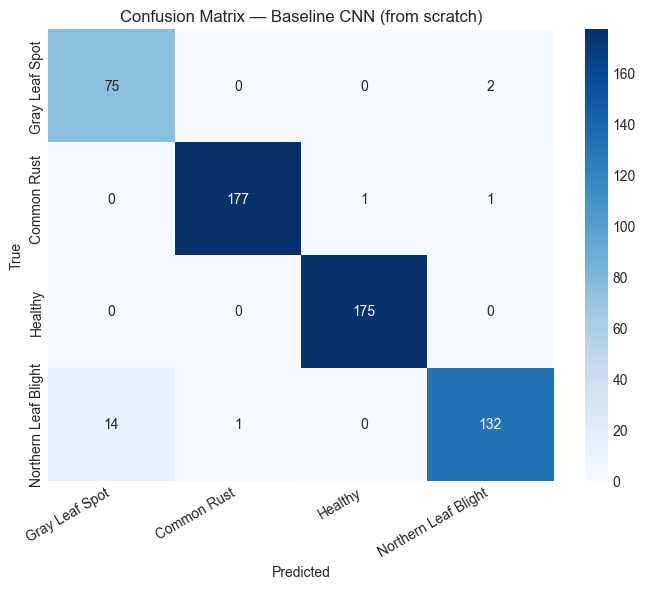

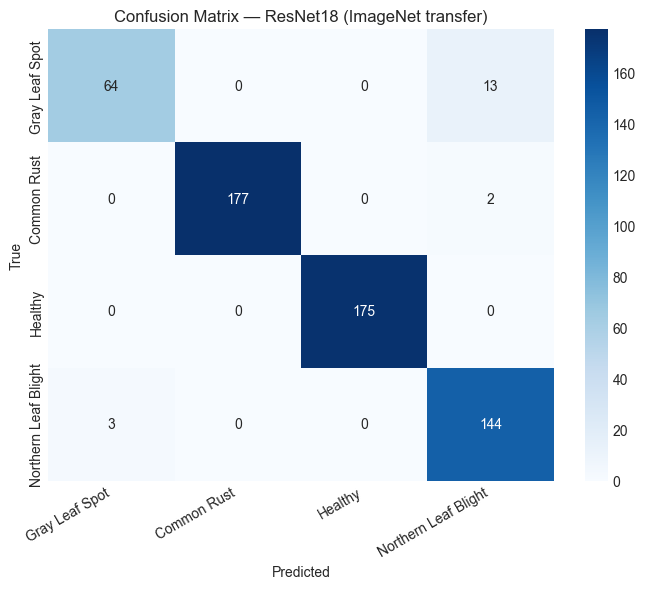

In [19]:
for name in MODELS:
    y_true, y_pred, _ = preds[name]
    fig = plot_confusion_matrix(y_true, y_pred, config.CLASS_SHORT_NAMES,
                                save_path=None, model_name=PRETTY[name])
    plt.show()

In [20]:
# Every off-diagonal cell, ranked — i.e. every distinct mistake each model makes.
from sklearn.metrics import confusion_matrix

for name in MODELS:
    y_true, y_pred, _ = preds[name]
    cm = confusion_matrix(y_true, y_pred)
    errors = [
        {"true": config.CLASS_SHORT_NAMES[i], "predicted": config.CLASS_SHORT_NAMES[j], "count": int(cm[i, j])}
        for i in range(len(cm)) for j in range(len(cm)) if i != j and cm[i, j] > 0
    ]
    err_df = pd.DataFrame(errors).sort_values("count", ascending=False).reset_index(drop=True)
    total = err_df["count"].sum()
    gls_nlb = err_df[
        ((err_df["true"] == "Gray Leaf Spot") & (err_df["predicted"] == "Northern Leaf Blight")) |
        ((err_df["true"] == "Northern Leaf Blight") & (err_df["predicted"] == "Gray Leaf Spot"))
    ]["count"].sum()

    print(f"\n{PRETTY[name]} — {total} errors total")
    display(err_df)
    print(f"  Gray Leaf Spot <-> Northern Leaf Blight confusion: {gls_nlb}/{total} "
          f"= {gls_nlb / total * 100:.0f}% of all errors")


Baseline CNN (from scratch) — 19 errors total


,true,predicted,count
0,Northern Leaf Blight,Gray Leaf Spot,14
1,Gray Leaf Spot,Northern Leaf Blight,2
2,Common Rust,Healthy,1
3,Common Rust,Northern Leaf Blight,1
4,Northern Leaf Blight,Common Rust,1


  Gray Leaf Spot <-> Northern Leaf Blight confusion: 16/19 = 84% of all errors

ResNet18 (ImageNet transfer) — 18 errors total


,true,predicted,count
0,Gray Leaf Spot,Northern Leaf Blight,13
1,Northern Leaf Blight,Gray Leaf Spot,3
2,Common Rust,Northern Leaf Blight,2


  Gray Leaf Spot <-> Northern Leaf Blight confusion: 16/18 = 89% of all errors


## 3.4 What the confusion matrices actually say

This is the most interesting result in the report, and it is invisible if you only read the accuracy
number.

**Both models score ~96.8% accuracy. They achieve it by making completely different mistakes.**

| | Baseline CNN | ResNet18 |
|---|---|---|
| Total errors / 578 | **19** | **18** |
| Healthy | **175 / 175 — perfect** | **175 / 175 — perfect** |
| Common Rust | 177 / 179 | 177 / 179 |
| Gray Leaf Spot | 75 / 77 (recall **0.97**) | 64 / 77 (recall **0.83**) |
| Northern Leaf Blight | 132 / 147 (recall **0.90**) | 144 / 147 (recall **0.98**) |
| Dominant error | **14× NLB → Gray Leaf Spot** | **13× Gray Leaf Spot → NLB** |
| Gray Leaf Spot ↔ NLB share of all errors | 16/19 = **84%** | 16/18 = **89%** |

Three findings:

1. **The Gray Leaf Spot ↔ Northern Leaf Blight pair is essentially the entire error budget** — 84%
   and 89% of all mistakes respectively. This is the visual-similarity challenge from Section 1.3(b),
   showing up exactly where predicted. Everything else the models do is close to solved.

2. **The two models have *opposite biases* on that pair.** The baseline over-predicts Gray Leaf Spot
   (it catches 97% of true GLS but drags 14 Northern Leaf Blight images in with them). ResNet18 does
   the reverse — it over-predicts Northern Leaf Blight (98% recall there) at the cost of missing 13
   of the 77 Gray Leaf Spot images. The baseline's aggressive class-weighting on the minority class
   pushed it one way; ResNet18's stronger features let it commit the other way.

3. **`Healthy` is solved: 175/175 for both models, zero errors, in both directions.** Nothing healthy
   is ever called diseased, and nothing diseased is ever called healthy. For a field-deployment
   screening tool this is the single most important property — the model never gives a farmer a false
   all-clear.

**Practical consequence.** If the deployment goal is *"never miss a diseased leaf"*, both models are
equally safe: no disease class ever leaks into `Healthy`. If the goal is *"tell the agronomist which
disease"*, then the baseline is the better Gray Leaf Spot detector (0.97 recall) and ResNet18 is the
better Northern Leaf Blight detector (0.98 recall). Neither dominates — and an ensemble of the two,
or simply reporting "GLS-or-NLB" as one merged advisory class, would outperform either alone.

### ROC and precision-recall curves

One-vs-rest, one curve per class. ROC-AUC is the metric that is insensitive to the decision threshold
and to class imbalance, so it is the fairest single number here. The precision-recall curves are the
more informative view for the minority class (Gray Leaf Spot).

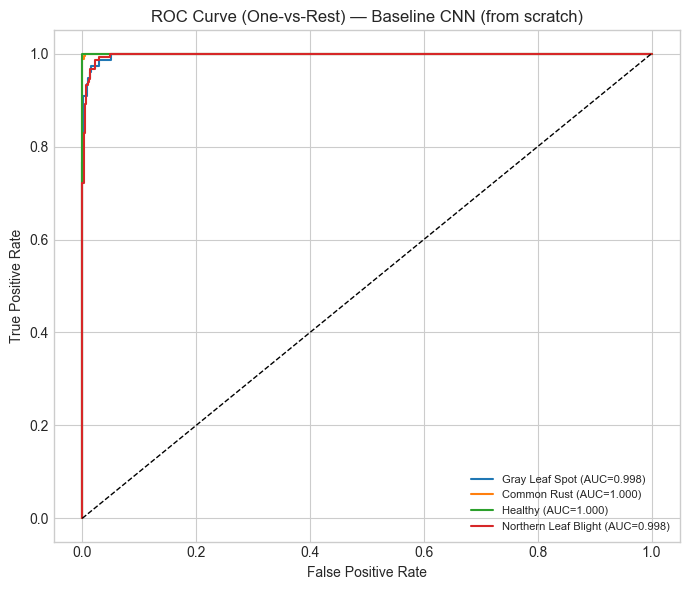

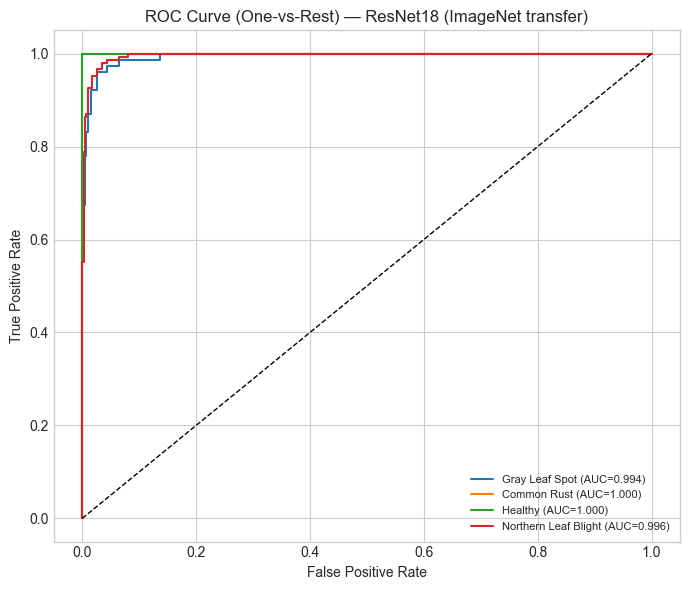

In [21]:
for name in MODELS:
    y_true, _, y_probs = preds[name]
    fig = plot_roc_curve(y_true, y_probs, config.CLASS_SHORT_NAMES, save_path=None, model_name=PRETTY[name])
    plt.show()

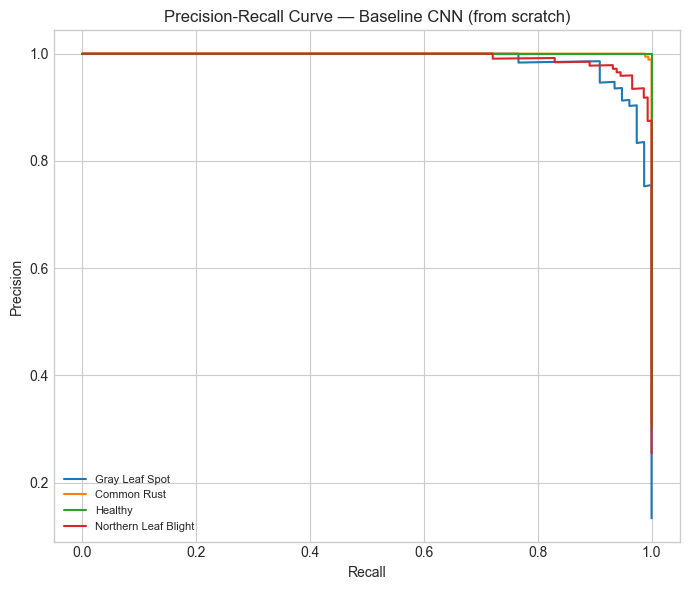

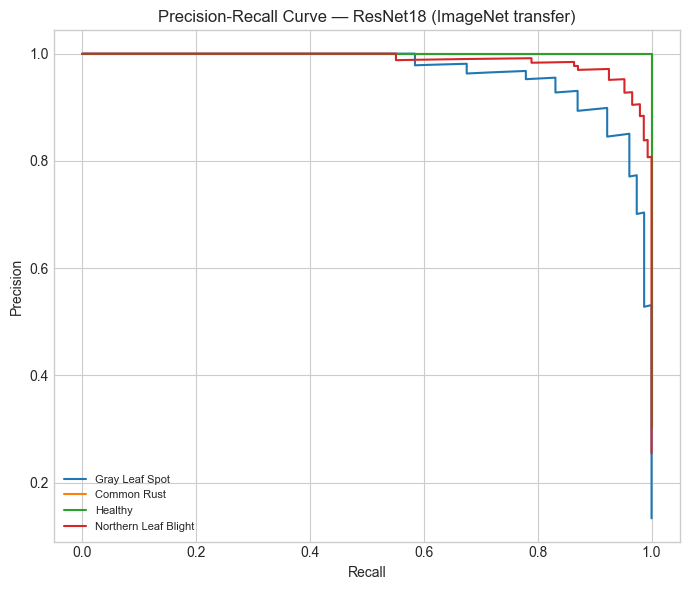

In [22]:
for name in MODELS:
    y_true, _, y_probs = preds[name]
    fig = plot_precision_recall_curve(y_true, y_probs, config.CLASS_SHORT_NAMES,
                                      save_path=None, model_name=PRETTY[name])
    plt.show()

<a id="task-3-5"></a>
## 3.5 Baseline vs. advanced model — the comparison

The assignment asks to *compare baseline vs. advanced model performance*. Below is the full
comparison, including the costs that a pure accuracy table hides.

In [23]:
comparison_rows = []
for name in MODELS:
    meta = json.loads((config.model_results_dir(name) / "training_meta.json").read_text(encoding="utf-8"))
    m = metrics[name]
    comparison_rows.append({
        "model": name,
        "accuracy": round(m["accuracy"], 4),
        "precision_macro": round(m["precision_macro"], 4),
        "recall_macro": round(m["recall_macro"], 4),
        "f1_macro": round(m["f1_macro"], 4),
        "roc_auc_macro": round(m["roc_auc_macro"], 4),
        "params": m["num_parameters"],
        "size_MB": m["model_size_mb"],
        "train_time_min": round(meta["training_time_seconds"] / 60, 1),
        "inference_ms_per_image": round(m["avg_inference_time_ms"], 1),
        "epochs_run": meta["epochs_run"],
    })

comp = pd.DataFrame(comparison_rows).set_index("model")
display(comp)   # models as rows: keeps one dtype per column (a transpose would force scientific notation)

# Deltas are computed from the UNROUNDED metrics, so they do not inherit the 4-dp display rounding.
mb, mr = metrics["baseline"], metrics["resnet18"]
print("ResNet18 relative to the baseline CNN:")
print(f"  accuracy      : {(mr['accuracy'] - mb['accuracy']) * 100:+.2f} pp"
      f"  ({int(round((mr['accuracy'] - mb['accuracy']) * len(test_ds)))} image out of {len(test_ds)})")
print(f"  F1 (macro)    : {(mr['f1_macro'] - mb['f1_macro']) * 100:+.2f} pp")
print(f"  ROC-AUC(macro): {(mr['roc_auc_macro'] - mb['roc_auc_macro']) * 100:+.2f} pp")
print(f"  parameters    : {mr['num_parameters'] / mb['num_parameters']:.1f}x more")
print(f"  disk size     : {mr['model_size_mb'] / mb['model_size_mb']:.1f}x larger")
print(f"  training time : {comp.loc['resnet18', 'train_time_min'] / comp.loc['baseline', 'train_time_min']:.1f}x longer")
print(f"  inference     : {mr['avg_inference_time_ms'] / mb['avg_inference_time_ms']:.2f}x slower "
      f"(re-measured live; varies by machine and load)")

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro,params,size_MB,train_time_min,inference_ms_per_image,epochs_run
model,,,,,,,,,,
baseline,0.9671,0.9523,0.9652,0.9571,0.9989,422788,1.63,104.4,24.9,30
resnet18,0.9689,0.9652,0.9499,0.9561,0.9974,11178564,42.72,154.4,30.0,26


ResNet18 relative to the baseline CNN:
  accuracy      : +0.17 pp  (1 image out of 578)
  F1 (macro)    : -0.10 pp
  ROC-AUC(macro): -0.15 pp
  parameters    : 26.4x more
  disk size     : 26.2x larger
  training time : 1.5x longer
  inference     : 1.20x slower (re-measured live; varies by machine and load)


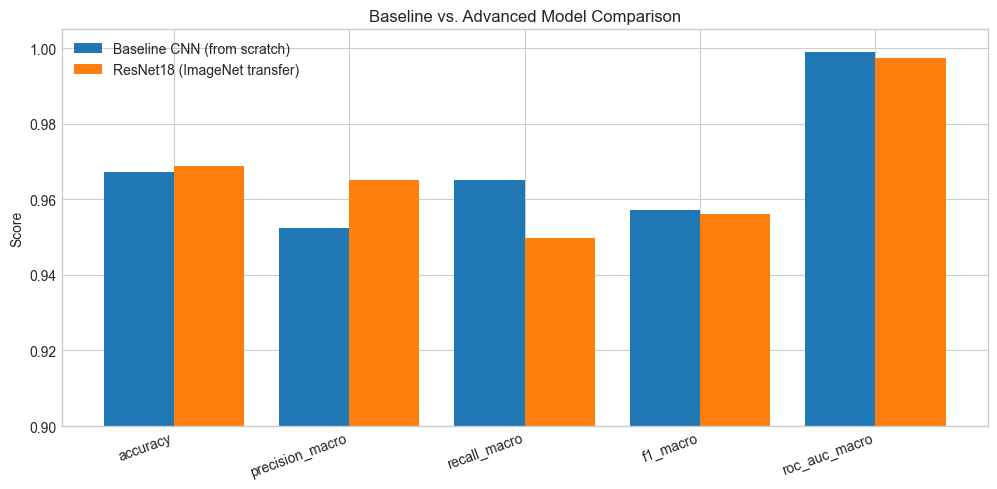

In [24]:
fig = plot_model_comparison(
    {PRETTY[n]: metrics[n] for n in MODELS},
    metrics_to_plot=["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"],
    save_path=None,
)
plt.ylim(0.90, 1.005)   # zoom: the differences are invisible on a 0-1 axis
plt.show()

### Verdict: transfer learning did **not** pay off on this dataset

This is not the expected textbook result, so it is worth stating precisely.

**ResNet18 wins on accuracy by +0.17 pp. That is 1 image out of 578** (18 errors vs 19). On a test
set this size, the 95% binomial confidence interval on a ~96.8% accuracy is roughly ±1.4 pp — so a
one-image difference is **statistically indistinguishable from noise**.

And on the two metrics that are *robust to class imbalance*, the baseline is actually **ahead**:

| Metric | Baseline | ResNet18 | Winner |
|---|---:|---:|:---|
| Accuracy | 0.9671 | **0.9689** | ResNet18 (by 1 image) |
| **F1 (macro)** | **0.9571** | 0.9561 | **Baseline** |
| **ROC-AUC (macro)** | **0.9989** | 0.9974 | **Baseline** |
| Precision (macro) | 0.9523 | **0.9652** | ResNet18 |
| Recall (macro) | **0.9652** | 0.9499 | **Baseline** |

Now the costs. ResNet18 is **26× larger** (11.2 M vs 423 K parameters), **26× heavier on disk**
(42.7 MB vs 1.63 MB), **1.5× slower to train** (154 min vs 104 min), and **~1.2–1.3× slower at
inference** (25.9 ms vs 34.8 ms per image in the canonical `evaluate.py` run on CPU — the table above
re-measures this live, so the exact figure moves with machine and load).

**26× the parameters, 1.5× the training time, for one more correct image — and a *lower* macro-F1.**

### Why? Three reasons.

1. **The task is too easy for the capacity on offer.** Three of the four classes (Healthy, Common
   Rust, and largely Northern Leaf Blight) are separable on coarse colour and texture cues that a
   4-block CNN learns comfortably from 2,696 images. ImageNet features add nothing there. Both models
   are pinned against the same ceiling, and that ceiling is set by the Gray Leaf Spot ↔ Northern Leaf
   Blight ambiguity (Section 3.4) — which is a property of the *labels*, not of the *architecture*.

2. **ImageNet features are a weak prior for leaf-lesion texture.** ResNet18's pretrained filters were
   tuned to discriminate 1,000 object categories — dogs, cars, furniture — where shape and global
   structure dominate. Fine-grained necrotic-lesion morphology on a monochrome-green background is
   out of distribution. The transfer is real but shallow.

3. **11.2 M parameters on 2,696 images is a bad ratio.** Section 2.3 showed ResNet18's validation
   loss bottoming out at epoch 19 and early stopping firing at 26, with `val_loss / train_loss = 3.3`.
   It spent its extra capacity memorising, not generalising. The baseline, at 423 K parameters, never
   had that option — and never overfit.

### Which model would ship?

**The baseline CNN.** It matches ResNet18 within noise on every metric, beats it on macro-F1 and
macro ROC-AUC, and is 26× smaller and 1.3× faster — a decisive advantage for the realistic deployment
target here, which is an offline mobile app in a field with no connectivity. The 1.63 MB checkpoint
fits in an app bundle; the 42.7 MB one is a download.

**The honest general lesson:** "use a bigger pretrained model" is a good default, not a law. On a
small, low-diversity, near-saturated dataset it buys nothing and costs a lot. The experiment was
worth running precisely because it could have come out the other way — and reporting that it did not
is more useful than quietly presenting only the ResNet numbers.

## 3.6 Sample predictions

The assignment's deliverables ask for *sample predictions*. Below: the images each model got wrong.
These are the hard cases — look at how similar the lesions are.

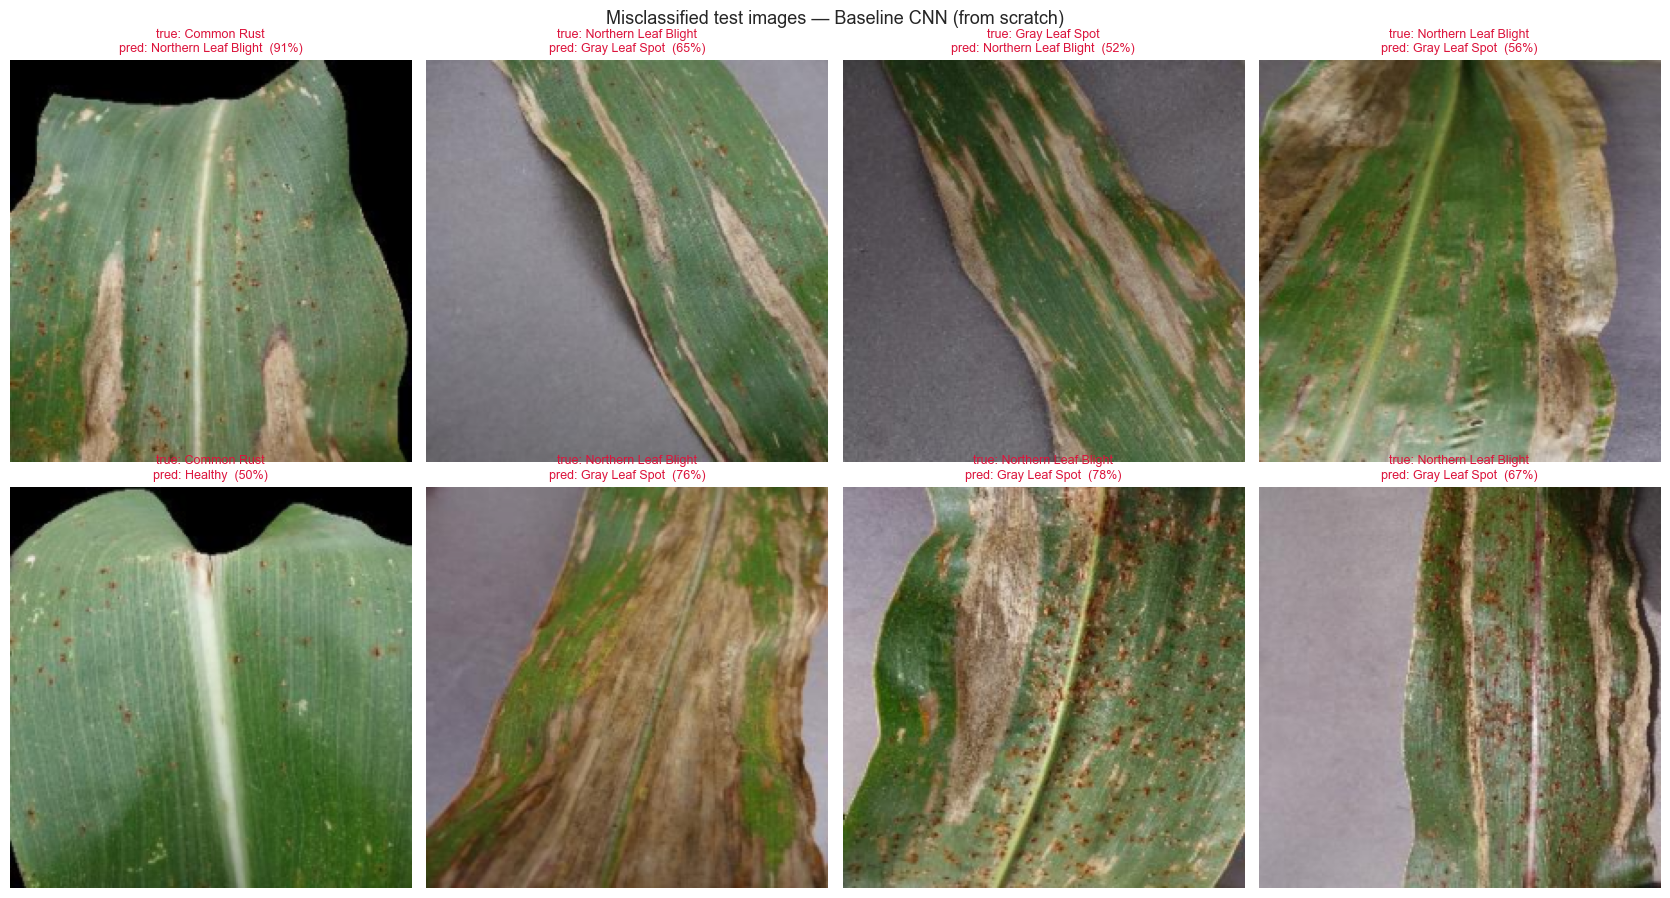

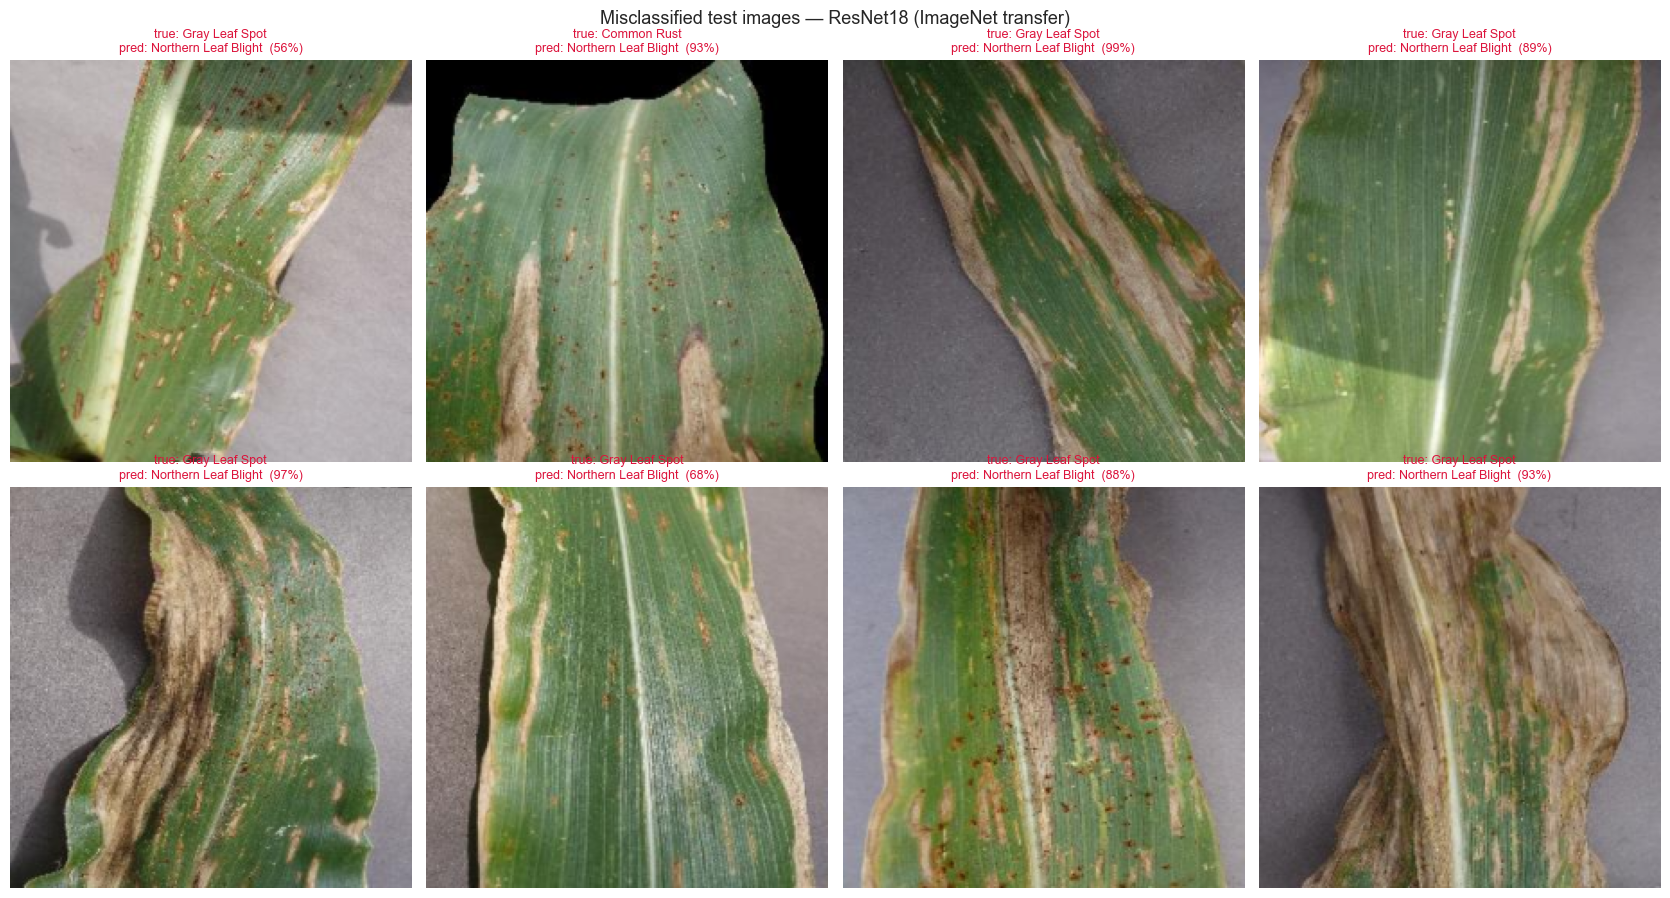

In [25]:
def show_predictions(name, only_errors=True, n=8):
    y_true, y_pred, y_probs = preds[name]
    idx = np.where(y_true != y_pred)[0] if only_errors else np.arange(len(y_true))
    if len(idx) == 0:
        print(f"{PRETTY[name]}: no errors to show.")
        return
    idx = idx[:n]

    cols = min(4, len(idx))
    rows = int(np.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4.6 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idx):
        img, _ = test_ds[int(i)]
        ax.imshow(denormalize(img))
        t = config.CLASS_SHORT_NAMES[y_true[i]]
        p = config.CLASS_SHORT_NAMES[y_pred[i]]
        conf = y_probs[i][y_pred[i]]
        ax.set_title(f"true: {t}\npred: {p}  ({conf:.0%})", fontsize=9,
                     color="crimson" if t != p else "green")
        ax.axis("off")
    for ax in axes[len(idx):]:
        ax.axis("off")

    kind = "Misclassified" if only_errors else "Sample"
    fig.suptitle(f"{kind} test images — {PRETTY[name]}", fontsize=13)
    fig.tight_layout()
    plt.show()


for name in MODELS:
    show_predictions(name, only_errors=True, n=8)

In [26]:
# Confidence calibration: is the model at least *unsure* when it is wrong?
print("Mean confidence assigned to the predicted class\n")
cal = []
for name in MODELS:
    y_true, y_pred, y_probs = preds[name]
    conf = y_probs[np.arange(len(y_pred)), y_pred]
    correct = y_true == y_pred
    cal.append({
        "model": PRETTY[name],
        "when correct": round(conf[correct].mean(), 4),
        "when wrong": round(conf[~correct].mean(), 4),
        "gap": round(conf[correct].mean() - conf[~correct].mean(), 4),
    })
display(pd.DataFrame(cal).set_index("model"))
print("A large positive gap means the model's confidence is a usable signal:")
print("low-confidence predictions can be routed to a human agronomist for review.")

Mean confidence assigned to the predicted class



,when correct,when wrong,gap
model,,,
Baseline CNN (from scratch),0.9756,0.6600,0.3155
ResNet18 (ImageNet transfer),0.9740,0.7653,0.2087


A large positive gap means the model's confidence is a usable signal:
low-confidence predictions can be routed to a human agronomist for review.


<a id="task-4"></a>
# Task 4 — Deliverables & Conclusion

---

## Deliverables checklist

| Required deliverable | Where it lives | Status |
|---|---|---|
| **Technical report** — dataset, preprocessing, model design, evaluation | `README.md` + this notebook (Sections 1–3) | Complete |
| **Code notebook** — well-commented, reproducible | this file | Complete |
| **Presentation** — curves, confusion matrix, sample predictions | `plots/` (all PNGs regenerated by `evaluate.py`) | Assets ready |
| Reproducible pipeline | `config.set_seed(42)`, seeded manifests, `requirements.txt` | Complete |
| Interactive demo | `streamlit run app.py` | Complete |

### Assignment tasks, point by point

| Task | Status | Evidence |
|---|---|---|
| Choose a dataset | Done | PlantVillage corn subset, 3,852 images, 4 classes (§1.1) |
| Preprocessing: resizing, normalization | Done | 224×224 + ImageNet mean/std (§1.2) |
| Augmentation: rotation, flipping, noise injection | Done | All three, plus jitter/affine/perspective (§1.2) |
| Document dataset challenges | Done | Imbalance 2.32:1, GLS↔NLB similarity, noise, resolution (§1.3) |
| Implement a CNN baseline | Done | `CustomCNN`, 423 K params, from scratch (§2.1) |
| Implement one advanced model | Done | ResNet18, ImageNet-pretrained, fine-tuned (§2.1) |
| Hyperparameter tuning | **Partial** | LR tuned online by `ReduceLROnPlateau`; epochs by early stopping. **Grid search over batch size / optimizer not executed** (§2.4) |
| Regularization: dropout, weight decay | Done | Dropout 0.4, wd 1e-4, BatchNorm, early stopping (§2.2) |
| Monitor overfitting | Done | Curves + generalization-gap table; early stopping fired on ResNet18 at epoch 26 (§2.3) |
| Metrics: accuracy, precision, recall, F1, ROC-AUC | Done | Macro + weighted (§3.2) |
| Confusion matrices | Done | Both models, plus a ranked error breakdown (§3.3) |
| Training/validation curves | Done | From the real training logs (§2.3) |
| Compare baseline vs. advanced | Done | Full cost/benefit comparison + verdict (§3.5) |

The one genuine gap is the hyperparameter grid search (§2.4). It is documented rather than fabricated.
Running `python tune.py --model baseline --epochs 5 --trials 6` closes it.

---

## Conclusion

**Headline.** Both models classify corn leaf disease at ~96.8% test accuracy on 578 held-out images.
The baseline CNN reaches 96.71% (macro-F1 0.9571, macro ROC-AUC 0.9989); the ImageNet-pretrained
ResNet18 reaches 96.89% (macro-F1 0.9561, macro ROC-AUC 0.9974).

**Four findings worth carrying forward:**

1. **The advanced model did not beat the baseline in any way that matters.** ResNet18's +0.17 pp
   accuracy edge is exactly **one image out of 578** — well inside the ±1.4 pp confidence interval of
   this test set — and it *loses* on macro-F1 and macro ROC-AUC, the two metrics that are robust to
   the 2.32:1 class imbalance. It costs 26× the parameters, 26× the disk, and 1.5× the training time
   to get there. On this dataset, transfer learning bought nothing.

2. **The error budget is one confusable pair, not a general weakness.** Gray Leaf Spot ↔ Northern
   Leaf Blight accounts for 84% of the baseline's errors and 89% of ResNet18's. Both diseases produce
   elongated grey-tan lesions along the leaf veins. This is a property of the label space, and no
   architecture or augmentation change will fix it — better data (higher-resolution close-ups of
   lesion margins) or a merged advisory class would.

3. **The two models fail in opposite directions on that pair**, which is genuinely useful: the
   baseline is the better Gray Leaf Spot detector (recall 0.97 vs 0.83) and ResNet18 the better
   Northern Leaf Blight detector (recall 0.98 vs 0.90). Their errors are anti-correlated, so an
   ensemble would beat both — the clearest next experiment.

4. **`Healthy` is perfectly separated — 175/175, both models, zero errors in both directions.** No
   diseased leaf is ever called healthy, and no healthy leaf is ever called diseased. For a screening
   tool, this false-negative rate of zero on the safety-critical class matters more than the last
   fraction of a percent of accuracy.

**What would ship: the baseline CNN.** It is statistically indistinguishable from ResNet18 on
accuracy, better on the imbalance-robust metrics, 26× smaller (1.63 MB vs 42.7 MB), and ~1.2–1.3×
faster per image — which is what an offline mobile app used in a field without connectivity actually
needs.

**Next steps, in order of expected value:**

1. Run the hyperparameter grid search (§2.4) to close the outstanding requirement.
2. Ensemble the two models — their errors are anti-correlated, so this is nearly free accuracy.
3. Attack Gray Leaf Spot ↔ Northern Leaf Blight directly: collect more Gray Leaf Spot images (it is
   the minority class *and* the hardest), or train a dedicated 2-class discriminator that fires only
   when the 4-class model predicts either.
4. Apply Grad-CAM to confirm the models attend to lesions rather than to background soil or hands.
5. Validate on field photographs from outside PlantVillage — laboratory-style uniform backgrounds are
   the most likely source of a nasty generalization surprise.

---

*Corn Leaf Disease Classification — Image Analysis Group 9.
Models trained with `train.py`; this notebook loads those checkpoints and evaluates them read-only.*